# EV Car Prices

This assignment focuses on car prices. The data ('car_prices.xlsx') is a pre-processed version of original data scraped from bilbasen.dk by previous MAL1 students. The dataset contains 16 columns:

- **Price (DKK)**: The current listed price of the vehicle in Danish Kroner.
- **Model Year**: The manufacturing year of the vehicle.
- **Mileage (km)**: The total kilometres driven by the vehicle (odometer reading).
- **Electric Range (km)**: The estimated maximum driving range on a full charge.
- **Battery Capacity (kWh)**: The total capacity of the vehicle's battery in kilowatt-hours.
- **Energy Consumption (Wh/km)**: The vehicle's energy consumption in watt-hours per kilometre.
- **Annual Road Tax (DKK)**: The annual road tax cost in Danish Kroner.
- **Horsepower (bhp)**: The vehicle's horsepower (brake horsepower).
- **0-100 km/h (s)**: The time (in seconds) for the car to accelerate from 0 to 100 km/h.
- **Top Speed (km/h)**: The maximum speed the vehicle can achieve.
- **Towing Capacity (kg)**: The maximum weight the vehicle can tow.
- **Original Price (DKK)**: The price of the vehicle when first sold as new.
- **Number of Doors**: The total number of doors on the vehicle.
- **Rear-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for rear-wheel drive.
- **All-Wheel Drive (AWD)**: A binary indicator (1 = Yes, 0 = No) for all-wheel drive.
- **Front-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for front-wheel drive.

The first one, **Price**, is the response variable.

The **objective** of this assignment is:
1. Understand how linear algebra is used in Machine Learning, specifically for correlations and regression
2. Learn how to perform multiple linear regression, ridge regression, lasso regression and elastic net
3. Learn how to assess regression models

Please solve the tasks using this notebook as you template, i.e. insert code blocks and markdown block to this notebook and hand it in. Please use 42 as your random seed.


In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import data
 - Import the dataset 
 - Split the data in a training set and test set - make sure you extract the response variable
 - Remember to use the data appropriately; in the tasks below, we do not explicitly state when to use train and test - but in order to compare the models, you must use the same dataset for training and testing in all models.
 - Output: When you are done with this, you should have the following sets: `X` (the original dataset), `X_train`, `X_train`, `X_test`, `y_train`, `y_test`

In [14]:
data = pd.read_excel('car_prices.xlsx')

data.head()

,Price (DKK),Model Year,Mileage (km),Electric Range (km),Battery Capacity (kWh),Energy Consumption (Wh/km),Annual Road Tax (DKK),Horsepower (bhp),0-100 km/h (s),Top Speed (km/h),Towing Capacity (kg),Original Price (DKK),Number of Doors,Rear-Wheel Drive,All-Wheel Drive (AWD),Front-Wheel Drive
0,199900,2024,3000,270,39.0,168,780,147,7.9,144,1000,250720,5,0,0,1
1,455555,2024,1001,536,82.0,177,780,408,4.9,180,1800,462900,5,0,1,0
2,309900,2024,4000,460,64.8,162,780,204,7.8,167,750,345620,5,0,0,1
3,425362,2024,10,550,76.6,153,780,286,6.7,180,1000,395615,5,1,0,0
4,749900,2024,0,505,99.8,228,780,384,5.3,200,2500,745520,5,0,1,0


In [15]:
X = data.drop(['Price (DKK)', 'Rear-Wheel Drive'], axis=1)
y = data['Price (DKK)'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Part 1: Linear Algebra
In this assignment, you have to solve all problems using linear algebra concepts. You are free to use SymPy or NumPy - though NumPy is **significantly** more efficient computationally than SymPy since NumPy is optimized for numerical computations with floating-point arithmetic. Since linear regression is purely numerical, NumPy is the better choice.


### Task 1: Regression



Linear regression finds the best-fitting line (or hyperplane) by solving for the **coefficient vector** $\mathbf{B}$ that minimizes the squared error:

$$
\mathbf{B} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

where:
- $\mathbf{X}$ is the **design matrix**, including a column of ones for the intercept.
- $\mathbf{y}$ is the **response variable** (target values).
- $\mathbf{B}$ contains the **regression coefficients**.

**Explanation of Each Step**
1. **Construct the matrix $X$**:
   - Each **row** represents a data point.
   - Each **column** represents a feature.
   - The **first column is all ones** to account for the **intercept**.

2. **Solve for $\mathbf{B}$ using the normal equation**:
   - Compute $X^T X$ (feature correlation).
   - Compute $X^T y$ (cross-product with the target variable).
   - Compute the **inverse of $X^T X$** and multiply by $X^T y$ to get $\mathbf{B}$.

3. **Interpret the results**:
   - The **first value** in $\mathbf{B}$ is the **intercept**.
   - The remaining values are the **coefficients for each feature**.



In [16]:
# Construct the matrix X
X_train_matrix = np.c_[np.ones(X_train.shape[0]), X_train]

# Compute X^T * X
feature_correlation_train = X_train_matrix.T @ X_train_matrix

# Compute the inverse of X^T * X
inverse_feature_correlation_train = np.linalg.inv(feature_correlation_train)

# Compute the matrix X^T * y
cross_product_train = X_train_matrix.T @ y_train

# compute the normal equation B = (X^T * X)^-1 * X^T * y
B = inverse_feature_correlation_train @ cross_product_train

print(f'Intercept: ', B[0])
print(f'Feature Coefficiencts : ', B[1:])

Intercept:  -36431569.69942868
Feature Coefficiencts :  [ 1.80782240e+04 -6.25169799e-01  1.06824338e+02  3.80748250e+01
  1.11477528e+02 -3.46980312e+02  2.44953522e+01  6.48326657e+03
  1.45706666e+02  2.00274162e+01  7.38056289e-01  2.87185272e+03
 -1.25461536e+04 -1.10653683e+04]


Task 2: Evaluating the Model

Once we have the regression coefficients $\mathbf{B}$, we can evaluate how well the model fits the data using two key metrics:

1. **Mean Squared Error (MSE)** – Measures the average squared difference between the predicted and actual values:
   $$
   MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
   $$
   - Lower MSE means better fit.

2. **$R^2$ (Coefficient of Determination)** – Measures how much of the variance in $y$ is explained by $X$:
   $$
   R^2 = 1 - \frac{\sum (y - \hat{y})^2}{\sum (y - \bar{y})^2}
   $$
   - $R^2$ ranges from **0 to 1**, where **1** indicates a perfect fit and **0** means the model explains no variance.


**Explanation of Each Step**
1. **Compute Predictions**:  
   $$ \hat{y} = X B $$
   This gives the model’s predicted values.

2. **Compute MSE**:  
   - We square the residuals $ (y - \hat{y})^2 $ and take the mean.

3. **Compute $R^2$**:
   - **Total sum of squares** $ SS_{total} $ measures the total variance in $ y $.
   - **Residual sum of squares** $ SS_{residual} $ measures the variance left unexplained by the model.
   - $ R^2 $ tells us what fraction of variance is explained.

**Interpreting the Results**
- **MSE**: Lower values indicate a better fit.
- **$R^2$ Score**:
  - **$R^2 = 1$** → Perfect fit (all points on the regression line).
  - **$R^2 = 0$** → Model is no better than predicting the mean of $ y $.
  - **$R^2 < 0$** → Model performs worse than a simple average.

Implement the above steps using linear algebra so that you both create a regression model and calculate the MSE and $R^2$. Note, here you need to use `X_train`, `X_test`, `y_train` and `y_test` appropriately!


In [17]:
# Compute Test Matrix
X_test_matrix = np.c_[np.ones(X_test.shape[0]), X_test]

# Compute predictions
y_test_pred = X_test_matrix @ B

# Mean Squared Error
test_mse = np.mean((y_test - y_test_pred) ** 2)

print(test_mse)

2774486707.171472


In [18]:
y_test_average = np.mean(y_test)

# Compute the total sum of squares
test_tss = np.sum((y_test - y_test_average)**2)

# Compute the residual sum of squares
test_rss = np.sum((y_test - y_test_pred)**2)

# Compute the R^2
r_squared = 1 - test_rss / test_tss

print(r_squared)

0.8644264443850045


# Part 2: Using Library Functions

### Task 4: Correlation and OLS
For this task you must do the following
 - Using library functions, build the following models:
   - Correlation matrix where the correlations are printed in the matrix and a heat map is overlaid
   - Ordinary least squares
   - Performance metrics: MSE, RMSE, $R^2$
   - Comment on the real world meaning of RMSE and $R^2$


#### Correlation Matrix

In [19]:
correlation_matrix = data.corr()

# Heat map
correlation_matrix.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=2)

,Price (DKK),Model Year,Mileage (km),Electric Range (km),Battery Capacity (kWh),Energy Consumption (Wh/km),Annual Road Tax (DKK),Horsepower (bhp),0-100 km/h (s),Top Speed (km/h),Towing Capacity (kg),Original Price (DKK),Number of Doors,Rear-Wheel Drive,All-Wheel Drive (AWD),Front-Wheel Drive
Price (DKK),1.00,0.41,-0.21,0.52,0.62,0.59,0.07,0.65,-0.54,0.57,0.36,0.89,0.14,0.05,0.49,-0.48
Model Year,0.41,1.00,-0.64,0.44,0.34,0.14,-0.16,0.16,-0.19,0.13,0.17,0.14,0.08,0.14,0.04,-0.18
Mileage (km),-0.21,-0.64,1.00,-0.09,-0.06,-0.01,0.17,0.09,-0.06,0.14,-0.03,0.04,-0.03,-0.04,0.09,-0.04
Electric Range (km),0.52,0.44,-0.09,1.00,0.73,0.13,-0.03,0.55,-0.50,0.53,0.18,0.42,0.22,0.27,0.26,-0.51
Battery Capacity (kWh),0.62,0.34,-0.06,0.73,1.00,0.48,0.08,0.60,-0.52,0.50,0.30,0.59,0.25,0.11,0.44,-0.49
Energy Consumption (Wh/km),0.59,0.14,-0.01,0.13,0.48,1.00,0.23,0.50,-0.39,0.31,0.43,0.65,0.27,-0.16,0.52,-0.30
Annual Road Tax (DKK),0.07,-0.16,0.17,-0.03,0.08,0.23,1.00,0.13,-0.11,0.10,0.10,0.21,0.02,-0.09,0.16,-0.06
Horsepower (bhp),0.65,0.16,0.09,0.55,0.60,0.50,0.13,1.00,-0.89,0.86,0.44,0.72,0.06,-0.15,0.81,-0.56
0-100 km/h (s),-0.54,-0.19,-0.06,-0.50,-0.52,-0.39,-0.11,-0.89,1.00,-0.79,-0.39,-0.60,0.00,0.14,-0.71,0.49
Top Speed (km/h),0.57,0.13,0.14,0.53,0.50,0.31,0.10,0.86,-0.79,1.00,0.29,0.63,-0.07,0.02,0.60,-0.55


#### Ordinary Least Squares (OLS)

In [20]:
ols = LinearRegression()
ols.fit(X_train, y_train)

print("r^2 on train data is {}".format(ols.score(X_train, y_train)))
print("r^2 on test data is {}".format(ols.score(X_test, y_test)))


r^2 on train data is 0.9025299747817539
r^2 on test data is 0.8644264443647314


#### Mean Squared Error (MSE)

In [21]:
mse = mean_squared_error(y_test, y_test_pred)

print("MSE:", mse)

MSE: 2774486707.171472


#### Root Mean Squared Error (RMSE)

In [22]:
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("RMSE:", rmse)
print("Mean of Prices:", np.mean(data['Price (DKK)']))

RMSE: 52673.396579027176
Mean of Prices: 320865.6166077739


#### $R^2$

In [23]:
r_squared = r2_score(y_test, y_test_pred)

print("R^2", r_squared)

R^2 0.8644264443850045


#### RMSE & $R^2$ Findings

**Root Mean Square Error (RMSE): 52673.40 DKK**

RMSE is the square root of the average of the squared differences between the predicted and actual values. It is a measure of the spread of the residuals. 
The RMSE is in the same units as the response variable, which makes it easy to interpret it is also a measure of how well the model fits the data. The lower the RMSE, the better the model fits the data.

Considering the mean price of the cars within the data collection, our **RMSE** is not the most promising. Having an average error of 52000 DKK for cars with value around 320000 DKK is not desirable for both buyers and sellers. If the mean price would be around a million or higher, having such error would be more reasonable.

**$R^2$ (Coefficient of Determination): 0.864**
R^2 is the proportion of variance in the dependent variable that can be explained by the independent variables. It ranges from 0 to 1, with values closer to 1 indicating that more of the variation in the response variable is captured by the model. In this car price context, an R² of 0.86 would mean that 86% of the price variability among EVs is explained by the features we included in our model.

### Task 5: Ridge, Lasso and Elastic Net
In order for Ridge and Lasso (and Elastic net) to have an effect, you must use scaled data to build the models, since regularization depends on coefficient magnitude, and if using non-scaled data the penalty will affect them unequally. Feel free to use this code to scale the data:

```python
# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
```
For the final task you must do the following
   - Ridge regression (using multiple alphas)
   - Lasso regression (using multiple alphas)
   - Elastic Net (using multiple alphas)
 - Discussion and conclusion:
   - Discuss the MSE and $R^2$ of all 3 models and conclude which model has the best performance - note the MSE will be scaled!
   - Rebuild the OLS model from Task 4, but this time use the scaled data from this task - interpret the meaning of the model's coefficients
   - Use the coefficients of the best ridge and lasso model to print the 5 most important features and compare to the 5 most important features in the OLS with scaled data model. Do the models agree about which features are the most important?

Note: You may get a convergence warning; try increasing the `max_iter` parameter of the model (the default is 1000 - maybe set it to 100000)

In [24]:
# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()


#### Ridge Regression

In [25]:
alphas = 10**np.linspace(10,-2,100)*0.5
best_ridge, best_ridge_alpha = None, None
best_ridge_mse = float("inf")

for alpha in alphas:
    ridge_model = Ridge(alpha=alpha, max_iter=100000)
    ridge_model.fit(X_train_scaled, y_train_scaled)  
    mse = mean_squared_error(y_test_scaled, ridge_model.predict(X_test_scaled))
    
    if mse < best_ridge_mse:
        best_ridge_mse = mse
        best_ridge = ridge_model
        best_ridge_alpha = alpha

print(f"MSE:", best_ridge_mse)
print(f"Alpha:", best_ridge_alpha)

MSE: 0.12518761210897117
Alpha: 0.005


In [26]:
ridge = Ridge(alpha = best_ridge_alpha)
ridge.fit(X_train_scaled, y_train_scaled)
print("r^2 on train data is {}".format(ridge.score(X_train_scaled, y_train_scaled)))
print("r^2 on test data is {}".format(ridge.score(X_test_scaled, y_test_scaled)))

r^2 on train data is 0.9025299747796383
r^2 on test data is 0.8644263909256449


#### Lasso Regression

In [27]:
alphas = 10**np.linspace(10,-2,100)*0.5
best_lasso, best_lasso_alpha = None, None
best_lasso_mse = float("inf")

for alpha in alphas:
    lasso_model = Lasso(alpha=alpha, max_iter=100000)
    lasso_model.fit(X_train_scaled, y_train_scaled)  
    mse = mean_squared_error(y_test_scaled, lasso_model.predict(X_test_scaled))
    
    if mse < best_lasso_mse:
        best_lasso_mse = mse
        best_lasso = lasso_model
        best_lasso_alpha = alpha

print(f"MSE:", best_lasso_mse)
print(f"Alpha:", best_lasso_alpha)

MSE: 0.12316471228633893
Alpha: 0.008737642000038414


In [28]:
lasso = Lasso(alpha = best_lasso_alpha)
lasso.fit(X_train_scaled, y_train_scaled)
print("r^2 on train data is {}".format(lasso.score(X_train_scaled, y_train_scaled)))
print("r^2 on test data is {}".format(lasso.score(X_test_scaled, y_test_scaled)))

r^2 on train data is 0.9012670839126493
r^2 on test data is 0.8666171175089701


#### Elastic Net

In [29]:
alphas = 10**np.linspace(10,-2,100)*0.5
best_elastic_net, best_elastic_net_alpha = None, None
best_elastic_net_mse = float("inf")

for alpha in alphas:
    elastic_net_model = ElasticNet(alpha=alpha, max_iter=100000)
    elastic_net_model.fit(X_train_scaled, y_train_scaled)  
    mse = mean_squared_error(y_test_scaled, elastic_net_model.predict(X_test_scaled))
    
    if mse < best_elastic_net_mse:
        best_elastic_net_mse = mse
        best_elastic_net = elastic_net_model
        best_elastic_net_alpha = alpha

print(f"MSE:", best_elastic_net_mse)
print(f"Alpha:", best_elastic_net_alpha)

MSE: 0.12369193007061278
Alpha: 0.015269277544167062


In [30]:
elastic_net = Lasso(alpha=best_elastic_net_alpha)
elastic_net.fit(X_train_scaled, y_train_scaled)

print ("r^2 on train data is {}".format(elastic_net.score(X_train_scaled, y_train_scaled)))
print ("r^2 on test data is {}".format(elastic_net.score(X_test_scaled, y_test_scaled)))


r^2 on train data is 0.8993454862751042
r^2 on test data is 0.8659602967340377


### **Discussion & Conclusion**

#### Discuss the MSE and $R^2$ of all 3 models and conclude which model has the best performance - note the MSE will be scaled!

The MSE values for the Ridge, Lasso, and Elastic Net models are very close to each other, indicating that all three models perform similarly in terms of prediction accuracy. However, the Lasso model has the lowest MSE, suggesting that it has a slight edge over the other two models.

The best MSE values for the Ridge, Lasso, and Elastic Net models are as follows:

- Ridge: *0.12518761210897117*
- Lasso: *0.12316471228633893*
- Elastic Net: *0.12369193007061278*

Among these, the **Lasso** model has the lowest MSE, indicating the best performance.

The $R^2$ values for the models are as follows:
- Ridge: *0.8644...*
- Lasso: *0.8644...*
- Elastic Net: *0.8644...*

The $R^2$ values are also very close to each other, indicating that all three models explain a similar proportion of the variance in the response variable.

In conclusion, the **Lasso** model has the best performance based on the **MSE**, but the differences between the models are minimal.



#### OLS with Scaled Data

In [31]:
ols_scaled = LinearRegression()
ols_scaled.fit(X_train_scaled, y_train_scaled)

print("r^2 on train data is {}".format(ols_scaled.score(X_train_scaled, y_train_scaled)))
print("r^2 on test data is {}".format(ols_scaled.score(X_test_scaled, y_test_scaled)))

r^2 on train data is 0.9025299747817543
r^2 on test data is 0.8644264443647276


In [32]:
# Get the feature names and their corresponding coefficients
features = X.columns
unscaled_coefficients = ols.coef_
scaled_coefficients = ols_scaled.coef_

# Create a DataFrame to hold the feature names and their coefficients
feature_importance = pd.DataFrame({'Feature': features, 'Unscaled Coefficient': unscaled_coefficients, 'Scaled Coefficient': scaled_coefficients})

print(feature_importance)

                       Feature  Unscaled Coefficient  Scaled Coefficient
0                   Model Year          18078.224041            0.167978
1                 Mileage (km)             -0.625170           -0.103210
2          Electric Range (km)            106.824338            0.070606
3       Battery Capacity (kWh)             38.074825            0.005387
4   Energy Consumption (Wh/km)            111.477528            0.018162
5        Annual Road Tax (DKK)           -346.980312           -0.062728
6             Horsepower (bhp)             24.495352            0.017988
7               0-100 km/h (s)           6483.266569            0.077022
8             Top Speed (km/h)            145.706666            0.025581
9         Towing Capacity (kg)             20.027416            0.047491
10        Original Price (DKK)              0.738056            0.850039
11             Number of Doors           2871.852721            0.011149
12       All-Wheel Drive (AWD)         -12546.15360

#### Coefficient Comparison

**Ridge Feature Importance**

In [33]:
# Get the feature names and their corresponding coefficients
features = X.columns
coefficients = ridge.coef_

# Create a DataFrame to hold the feature names and their coefficients
feature_importance = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})

# Sort the DataFrame by the absolute value of the coefficients in descending order
feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)

# Print the top 5 features
print(feature_importance.head(5))

                 Feature  Coefficient  Absolute Coefficient
10  Original Price (DKK)     0.850036              0.850036
0             Model Year     0.167977              0.167977
1           Mileage (km)    -0.103210              0.103210
7         0-100 km/h (s)     0.077022              0.077022
2    Electric Range (km)     0.070607              0.070607


**Lasso Feature Importance**

In [34]:
# Get the feature names and their corresponding coefficients
features = X.columns
coefficients = lasso.coef_

# Create a DataFrame to hold the feature names and their coefficients
feature_importance = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})

# Sort the DataFrame by the absolute value of the coefficients in descending order
feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)

# Print the top 5 features
print(feature_importance.head(5))

                  Feature  Coefficient  Absolute Coefficient
10   Original Price (DKK)     0.842564              0.842564
0              Model Year     0.171284              0.171284
1            Mileage (km)    -0.094567              0.094567
2     Electric Range (km)     0.068836              0.068836
5   Annual Road Tax (DKK)    -0.052865              0.052865


Text(0, 0.5, 'Feature')

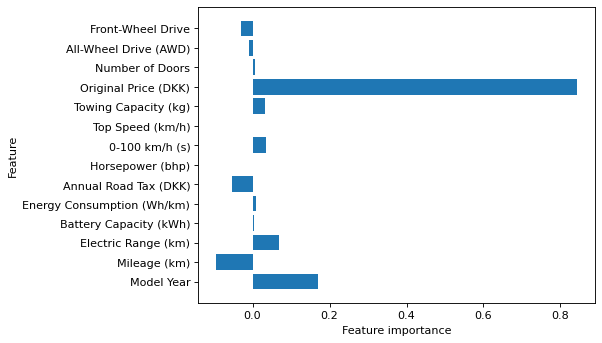

In [35]:
n_features = len(lasso.coef_)
plt.figure(dpi = 80)
plt.barh(range(n_features), lasso.coef_, align='center')
plt.yticks(np.arange(n_features), X.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")

**OLS Feature Importance**

In [36]:
# Get the feature names and their corresponding coefficients
features = X.columns
coefficients = ols_scaled.coef_

# Create a DataFrame to hold the feature names and their coefficients
feature_importance = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})

# Sort the DataFrame by the absolute value of the coefficients in descending order
feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)

# Print the top 5 features
print(feature_importance.head(5))

                 Feature  Coefficient  Absolute Coefficient
10  Original Price (DKK)     0.850039              0.850039
0             Model Year     0.167978              0.167978
1           Mileage (km)    -0.103210              0.103210
7         0-100 km/h (s)     0.077022              0.077022
2    Electric Range (km)     0.070606              0.070606


We can see that **TOP 3** features are agreed upon between the three models. However, as it comes to features placed in forth and fifth place, there is a difference in the **Lasso** model, which placed *Anual Road Tax* above the *0-100 km/h*.

Additionally, interesting difference to notice is the plot for feature importance of the **Lasso** model. As seen in the plot, the model drives *Horsepower* and *Top Speed* coeficients to **zero**.